<a href="https://colab.research.google.com/github/themehmi/Colab-Files/blob/main/Cross_Validation_and_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cross-Validation and Hyperparameter Tuning**

---

**What you will learn in this notebook:**
1. Why we need cross-validation
2. How K-Fold cross-validation works (with code)
3. Stratified K-Fold for imbalanced data
4. What hyperparameters are
5. Grid Search - trying every combination
6. Random Search - smarter, faster tuning
7. Comparing results and picking the best model


---

**Cross-validation (CV)** is a fundamental step in machine learning used to evaluate a model's performance and ensure it generalizes well to unseen data, rather than just memorizing the training set (overfitting).

**Here are the most widely used cross-validation techniques:**

### **1. K-Fold Cross-Validation**
This is the standard, go-to technique for most machine learning tasks.
* **How it works:** The dataset is shuffled and divided into $k$ equal-sized blocks (or "folds"). The model is trained on $k-1$ folds and tested on the remaining 1 fold. This process is repeated $k$ times, with each fold serving as the test set exactly once.
* **Pros:** Every data point gets to be in a test set exactly once, making the evaluation score highly reliable.
* **Use case:** General classification and regression tasks with moderately sized datasets.

<img src="https://media.geeksforgeeks.org/wp-content/uploads/20240511220432/K-Fold.PNG">



---




### **2. Stratified K-Fold Cross-Validation**
A variation of standard K-Fold designed specifically for classification problems.
* **How it works:** It splits the data into $k$ folds, but it enforces that each fold contains roughly the same proportion of target class labels as the complete dataset.
* **Pros:** Prevents scenarios where a fold might contain only a single class, which would ruin the training/testing phase for that iteration.
* **Use case:** Highly recommended for **imbalanced datasets** (e.g., fraud detection, where 99% of transactions are legitimate and 1% are fraudulent).

<img src="https://i.sstatic.net/XJZve.png">


---



### **3. Leave-One-Out Cross-Validation (LOOCV)**
This is an extreme version of K-Fold where $k$ equals the total number of samples ($N$) in the dataset.
* **How it works:** For a dataset with $N$ samples, the model trains on $N-1$ samples and tests on the single remaining sample. This is repeated $N$ times.
* **Pros:** Uses almost all the data for training, resulting in a model with low bias.
* **Cons:** Extremely computationally expensive. If you have 10,000 rows, you must train the model 10,000 times.
* **Use case:** Very small datasets where you cannot afford to hold out large chunks for testing.

<img src="https://miro.medium.com/v2/resize:fit:1400/1*zFMgKmUDs9lO6gyUtLb0UQ.png">


---



### **4. Time Series Split (Rolling Cross-Validation)**
Standard CV techniques assume data is independent and identically distributed (I.I.D.). This assumption fails in time-series data, where looking at future data to predict past data causes "data leakage."
* **How it works:** The data is ordered chronologically. In the first iteration, it trains on the oldest data and tests on the next slice. In the next iteration, the training set expands to include the previous test slice, and tests on the next chronological slice.
* **Pros:** Respects the temporal order of data, ensuring you never train on the "future" to predict the "past."
* **Use case:** Stock market prediction, weather forecasting, sales forecasting.
<img src="https://media.licdn.com/dms/image/v2/D5612AQG4IVWx1txMxw/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1729704761810?e=2147483647&v=beta&t=1p0i0souTJtiaPCpMrx8_xaWTCXlNbhPziI-HXCexW4">


---



### **5. Group K-Fold Cross-Validation**
Used when the dataset contains distinct, logically grouped data points, and you want to ensure that the same group does not appear in both the training and testing sets.
* **How it works:** Like K-Fold, but instead of splitting samples randomly, it splits based on a specified group identifier.
* **Pros:** Prevents data leakage across groups.
* **Use case:** Medical data (e.g., you have multiple X-rays from the same patient. You want the patient to be strictly in either the train or test set, otherwise, the model might just learn to recognize the patient's specific anatomy rather than the disease).

***


The major difference between Stratified K-Fold and Group K-Fold comes down to **what problem they are trying to solve** when splitting the data.

* **Stratified K-Fold** looks at your **Target Variable (Y)** to ensure class proportions are balanced.
* **Group K-Fold** looks at your **Input Data Source (X)** to prevent data leakage from related samples.

Here is a breakdown of how they differ in practice:

### 1. Stratified K-Fold: Solving "Class Imbalance"
This technique ensures that the ratio of the classes you are trying to predict remains identical across all training and testing folds.

* **The Problem it Solves:** Imagine you are building a model to detect a rare disease, where 90% of your dataset is "Healthy" and 10% is "Sick." If you use standard random splitting, one of your test folds might accidentally end up with 100% "Healthy" patients and 0 "Sick" patients. The model can't be evaluated properly on that fold.
* **The Solution:** Stratified K-Fold forces every single fold to maintain that exact 90/10 split.
* **Focus:** It groups by the **Label / Target Variable**.

### 2. Group K-Fold: Solving "Data Leakage"
This technique ensures that data points originating from the same source (the same "group") are kept strictly together. A group must be entirely in the training set or entirely in the testing set—never split between the two.

* **The Problem it Solves:** Imagine you have a medical dataset with 1,000 X-ray images, but they come from only 100 patients (10 X-rays per patient). If you use a standard split, Patient A might have 8 X-rays in the training set and 2 in the test set.
    * *The Danger:* The model might just learn to recognize Patient A's unique bone structure or jewelry, rather than actually learning to detect the disease. When it sees Patient A in the test set, it guesses correctly for the wrong reasons. This is a massive data leak.
* **The Solution:** Group K-Fold guarantees that all 10 X-rays from Patient A will either be used for training *or* for testing, but never both.
* **Focus:** It groups by an **Identifier / Feature** (e.g., Patient ID, Session ID, Device ID).

---

### Summary Comparison

| Feature | Stratified K-Fold | Group K-Fold |
| :--- | :--- | :--- |
| **Primary Goal** | Maintain equal class distribution. | Prevent data leakage across related samples. |
| **What dictates the split?** | The Target Label (e.g., `is_fraud`, `has_disease`). | A Group ID (e.g., `user_id`, `patient_id`, `session_id`). |
| **Use Case Example** | Credit card fraud detection (where fraud is only 0.1% of data). | Voice recognition (where you have multiple audio clips from the same speaker). |
| **Can they be combined?** | Yes. Scikit-learn offers `StratifiedGroupKFold` if you have imbalanced data *and* overlapping groups. | Yes. |

**K-Fold**

In [44]:
#load dataset and import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Dataset
from sklearn.datasets import load_iris

# Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Cross-validation tools
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Metrics
from sklearn.metrics import accuracy_score

print("All libraries imported successfully!")

#load csv
path="https://raw.githubusercontent.com/lovnishverma/datasets/refs/heads/main/insurance.csv"
df = pd.read_csv(path)

All libraries imported successfully!


In [45]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [46]:
# encoding on columns

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

In [47]:
# separate features and target

X = df.drop('smoker', axis=1)
y = df['smoker']

In [48]:
# test train split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [49]:
# Model Training
model = RandomForestClassifier(n_estimators=10, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
for train_index, test_index in kf.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  fold_accuracies.append(accuracy)

print(f"Accuracy for each fold: {fold_accuracies}")
print(f"Mean accuracy: {np.mean(fold_accuracies)}")

Accuracy for each fold: [0.9701492537313433, 0.9514925373134329, 0.9440298507462687, 0.9288389513108615, 0.9662921348314607]
Mean accuracy: 0.9521605455866734


In [50]:
#shortcut
model = RandomForestClassifier(n_estimators=10, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("cross_val_score result:")
print(f"  Scores per fold : {scores}")
print(f"  Mean Accuracy   : {scores.mean():.4f}")
print(f"  Std Deviation   : {scores.std():.4f}")

cross_val_score result:
  Scores per fold : [0.97014925 0.95149254 0.94402985 0.92883895 0.96629213]
  Mean Accuracy   : 0.9522
  Std Deviation   : 0.0151


**Stratified K-Fold**

In [51]:
model = RandomForestClassifier(n_estimators=10, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
for train_index, test_index in skf.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  fold_accuracies.append(accuracy)

print(f"Accuracy for each fold: {fold_accuracies}")
print(f"Mean accuracy: {np.mean(fold_accuracies)}")

Accuracy for each fold: [0.9552238805970149, 0.9552238805970149, 0.9552238805970149, 0.9662921348314607, 0.9550561797752809]
Mean accuracy: 0.9574039912795573


In [52]:
#shortcut
model = RandomForestClassifier(n_estimators=10, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')

print("cross_val_score result:")
print(f"  Scores per fold : {scores}")
print(f"  Mean Accuracy   : {scores.mean():.4f}")
print(f"  Std Deviation   : {scores.std():.4f}")

cross_val_score result:
  Scores per fold : [0.95522388 0.95522388 0.95522388 0.96629213 0.95505618]
  Mean Accuracy   : 0.9574
  Std Deviation   : 0.0044


---

## What Are Hyperparameters?

A model has two kinds of parameters:

| Type | Who sets it? | Example |
|------|--------------|---------|
| **Parameters** | Learned from data during training | weights in neural network, split thresholds in decision tree |
| **Hyperparameters** | Set by YOU before training | number of trees, max depth, learning rate |

**Hyperparameter tuning** = finding the best values for these settings to maximize model performance.

### Common Hyperparameters of RandomForestClassifier

| Hyperparameter | What it controls | Typical range |
|----------------|-----------------|---------------|
| `n_estimators` | Number of trees | 10 – 500 |
| `max_depth` | How deep each tree grows | 2 – 20, or None |
| `min_samples_split` | Min samples needed to split a node | 2 – 20 |
| `max_features` | Features to consider at each split | 'sqrt', 'log2' |

**GridSearchCV**

In [53]:
# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [10, 50, 100],
    'max_depth':    [None, 3, 5],
    'min_samples_split': [2, 5]
}

model = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=1)
grid_search.fit(X, y)

print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))




Best parameters found:  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best cross-validation score: 0.9641


In [54]:
#evaluation
df_results = pd.DataFrame(grid_search.cv_results_)
df_results = df_results[['param_n_estimators', 'param_max_depth',
                          'param_min_samples_split', 'mean_test_score', 'rank_test_score']]
df_results = df_results.sort_values(by='rank_test_score').reset_index(drop=True)
df_results


,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
0,100,None,5,0.964132,1
1,100,None,2,0.961896,2
2,10,None,5,0.961124,3
3,50,None,2,0.957407,4
4,50,None,5,0.956661,5
5,100,5,5,0.956658,6
6,50,5,5,0.955917,7
7,50,5,2,0.955165,8
8,100,5,2,0.954422,9
9,10,None,2,0.954411,10


---

**Randomized Search CV**

**Random Search** doesn't try every combination. Instead, it **randomly samples** from the parameter space for a fixed number of iterations.

**Why use it?**
- Much faster than Grid Search when the parameter space is large
- Often finds nearly equally good results in a fraction of the time
- Allows you to search over continuous distributions (e.g., learning rate from 0.001 to 1.0)

> **Rule of thumb:** Start with Random Search to narrow down the range, then use Grid Search to fine-tune.

In [43]:
from scipy.stats import randint as sp_randint

# Define the hyperparameter to search
param_distributions={
    'n_estimators': sp_randint(10, 100),
    'max_depth':    [None,2,3,5,7,9],
    'min_samples_split': sp_randint(2, 20),
    'max_features': ['sqrt', 'log2', None]
}

model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=model, param_distributions=param_distributions,
    n_iter=20,             # try only 20 random combinations
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X, y)

print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: {:.4f}".format(random_search.best_score_))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters found:  {'max_depth': 7, 'max_features': None, 'min_samples_split': 4, 'n_estimators': 87}
Best cross-validation score: 0.9708


     FINAL COMPARISON OF ALL APPROACHES
  Baseline (default params)  : 0.9619
  After Grid Search CV       : 0.9641
  After Randomized Search CV : 0.9708


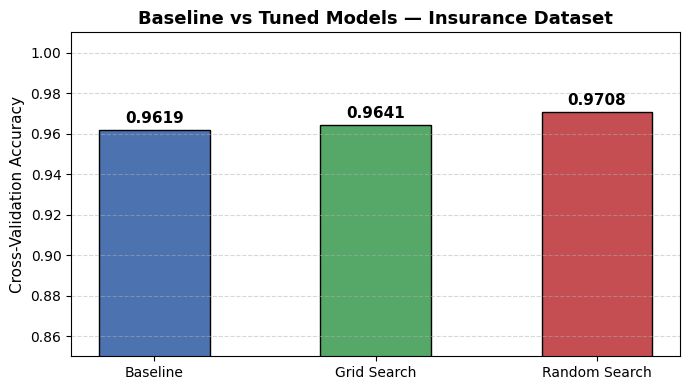

In [55]:
# Baseline: default model with no tuning
baseline = RandomForestClassifier(random_state=42)
baseline_score = cross_val_score(baseline, X, y, cv=5, scoring='accuracy').mean()

# Summary Table
print("=" * 55)
print("     FINAL COMPARISON OF ALL APPROACHES")
print("=" * 55)
print(f"  Baseline (default params)  : {baseline_score:.4f}")
print(f"  After Grid Search CV       : {grid_search.best_score_:.4f}")
print(f"  After Randomized Search CV : {random_search.best_score_:.4f}")
print("=" * 55)

# Bar Chart
labels  = ['Baseline', 'Grid Search', 'Random Search']
scores  = [baseline_score, grid_search.best_score_, random_search.best_score_]
colors  = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, scores, color=colors, width=0.5, edgecolor='black')

# Add value labels on top of bars
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0.85, 1.01)
ax.set_ylabel('Cross-Validation Accuracy', fontsize=11)
ax.set_title('Baseline vs Tuned Models — Insurance Dataset', fontsize=13, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()